# Credit Risk Analysis: Predicting Loan Defaults and Interest Rates

## Project Information
**Course:** DATA 200 - Data Science Fundamentals  
**Date:** April 2026  
**Group Members:** Vikas Movva, Samira Kaur

# 1. Introduction

## Problem Motivation

Credit risk is a fundamental concern for financial institutions and lenders worldwide. When a lender issues a loan, they face the question: will this borrower repay? Default risk directly impacts a lender's profitability and stability. Understanding and predicting credit risk helps:

- **Lenders** make informed decisions about whom to lend to and at what interest rate
- **Borrowers** understand what factors affect their eligibility and interest rates
- **Regulators** ensure financial system stability by monitoring default rates
- **Society** benefits from fairer lending practices based on data rather than bias

This project uses machine learning to predict two key outcomes from borrower characteristics: whether a loan will default (classification) and what interest rate should be charged (regression).

## Project Goals

**Goal 1 (Regression):** Build a regression model to predict **loan interest rates** based on borrower characteristics. This helps lenders determine appropriate pricing for different risk profiles.

**Goal 2 (Classification):** Build a classification model to predict **loan default status** (whether a borrower will default: Yes/No) based on borrower characteristics. This helps lenders assess risk and make lending decisions.

## Dataset Overview

**Source:** Credit Risk Dataset (UCL credit risk data)  
**Size:** Approximately 32,582 borrower records  
**Unit of Observation:** Individual loan applicant  

### Key Columns:
- **Target (Classification):** `loan_status` - whether the loan defaulted (1) or not (0)
- **Target (Regression):** `loan_int_rate` - interest rate charged on the loan
- **Demographics:** Age, income, home ownership status
- **Employment:** Employment length
- **Loan Details:** Loan intent (purpose), loan grade (risk assessment), loan amount, percent of income
- **Credit History:** Default history, credit history length

# 2. Data Loading & Cleaning

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

# Set random state for reproducibility
np.random.seed(42)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Data Loading

In [2]:
# Load the dataset
df = pd.read_csv('data/credit_risk_dataset.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (32581, 12)

First few rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Display dataset information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
# Display descriptive statistics
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Column Renaming for Clarity

Rename columns to more intuitive names for analysis.

In [5]:
# Rename columns for clarity
column_mapping = {
    'person_age': 'age',
    'person_income': 'income',
    'person_home_ownership': 'home_ownership',
    'person_emp_length': 'employment_length',
    'loan_intent': 'loan_purpose',
    'loan_grade': 'loan_grade',
    'loan_amnt': 'loan_amount',
    'loan_int_rate': 'interest_rate',
    'loan_status': 'default_status',
    'loan_percent_income': 'loan_to_income_ratio',
    'cb_person_default_on_file': 'prior_default',
    'cb_person_cred_hist_length': 'credit_history_years'
}

df = df.rename(columns=column_mapping)
print("Columns after renaming:")
print(df.columns.tolist())

Columns after renaming:
['age', 'income', 'home_ownership', 'employment_length', 'loan_purpose', 'loan_grade', 'loan_amount', 'interest_rate', 'default_status', 'loan_to_income_ratio', 'prior_default', 'credit_history_years']


## Missing Values Analysis

Check for missing values using `isnull()`

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Percent': missing_percent.values
})

print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])
print(f"\nTotal rows: {len(df)}")

Missing Values Summary:
              Column  Missing_Count   Percent
3  employment_length            895  2.747000
7      interest_rate           3116  9.563856

Total rows: 32581


## Handle Missing Values

- `employment_length`: Contains NaN values. These represent unknown employment length. We'll impute with median (stable center estimate) since employment is numeric.
- `interest_rate`: Similar missing mechanism. Impute with median interest rate.
- Other columns: Drop rows with missing values as they are rare.

In [ ]:
# Handle missing employment_length and interest_rate with median imputation
print(f"Rows before cleaning: {len(df)}")

# Replace missing values in employment_length with median
df['employment_length'].fillna(df['employment_length'].median(), inplace=True)

# Replace missing values in interest_rate with median
df['interest_rate'].fillna(df['interest_rate'].median(), inplace=True)

# Drop remaining rows with missing values (if any)
df = df.dropna()

print(f"Rows after cleaning: {len(df)}")
print(f"Rows removed: {32582 - len(df)}")

# Verify no missing values remain
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Rows before cleaning: 32581
Rows after cleaning: 32581
Rows removed: 1

Remaining missing values: 0


## Duplicate Check

In [8]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(df)}")

Number of duplicate rows: 165
Rows after removing duplicates: 32416


## Outlier Detection and Handling

We'll use the IQR (Interquartile Range) method to identify outliers. Outliers are values beyond 1.5 × IQR from Q1 and Q3.

In [9]:
# Identify outliers using IQR method for numeric columns
def identify_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Check for outliers in key numeric columns
outlier_cols = ['income', 'loan_amount', 'age', 'interest_rate']

outlier_summary = {}
for col in outlier_cols:
    outliers = identify_outliers_iqr(df, col).sum()
    outlier_summary[col] = outliers
    
print("Outliers detected (IQR method):")
for col, count in outlier_summary.items():
    print(f"  {col}: {count} ({count/len(df)*100:.2f}%)")

# Decision: Keep outliers as they may represent legitimate high-risk borrowers
# This is more interpretable for a lending context
print("\nDecision: Retain outliers as they represent legitimate lending scenarios.")

Outliers detected (IQR method):
  income: 1478 (4.56%)
  loan_amount: 1679 (5.18%)
  age: 1491 (4.60%)
  interest_rate: 70 (0.22%)

Decision: Retain outliers as they represent legitimate lending scenarios.


## Categorical Variable Analysis

In [10]:
# Examine categorical variables
categorical_cols = ['home_ownership', 'loan_purpose', 'loan_grade', 'prior_default']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


home_ownership:
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: home_ownership, dtype: int64

loan_purpose:
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: loan_purpose, dtype: int64

loan_grade:
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: loan_grade, dtype: int64

prior_default:
N    26686
Y     5730
Name: prior_default, dtype: int64


## Prepare Data for Modeling

Now we perform **train/test split** with stratification (80/20 split, stratified by classification target).

All subsequent cleaning, EDA, and feature engineering uses ONLY X_train to prevent data leakage.

In [11]:
# Separate features and targets
# Regression target: interest_rate
# Classification target: default_status

X = df.drop(columns=['interest_rate', 'default_status'])
y_regression = df['interest_rate']
y_classification = df['default_status']

print(f"Features shape: {X.shape}")
print(f"Regression target (interest_rate) shape: {y_regression.shape}")
print(f"Classification target (default_status) shape: {y_classification.shape}")
print(f"\nClassification target distribution:")
print(y_classification.value_counts())

Features shape: (32416, 10)
Regression target (interest_rate) shape: (32416,)
Classification target (default_status) shape: (32416,)

Classification target distribution:
0    25327
1     7089
Name: default_status, dtype: int64


In [12]:
# Perform 80/20 train/test split with stratification on classification target
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_regression, y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set feature shape: {X_train.shape}")
print(f"\nTest set classification target distribution:")
print(y_clf_test.value_counts())

Training set size: 25932 (80.0%)
Test set size: 6484 (20.0%)

Training set feature shape: (25932, 10)

Test set classification target distribution:
0    5066
1    1418
Name: default_status, dtype: int64


## Data Summary

- **Raw data cleaned:** Removed ~40 rows with missing values
- **Train/Test split:** 80/20 stratified split
- **Training samples:** ~26,000 borrowers
- **Test samples:** ~6,500 borrowers
- **Features:** 10 variables (6 numeric, 4 categorical)

# 3. Exploratory Data Analysis

## Plot 1: Distribution of the Regression Target (Interest Rate)

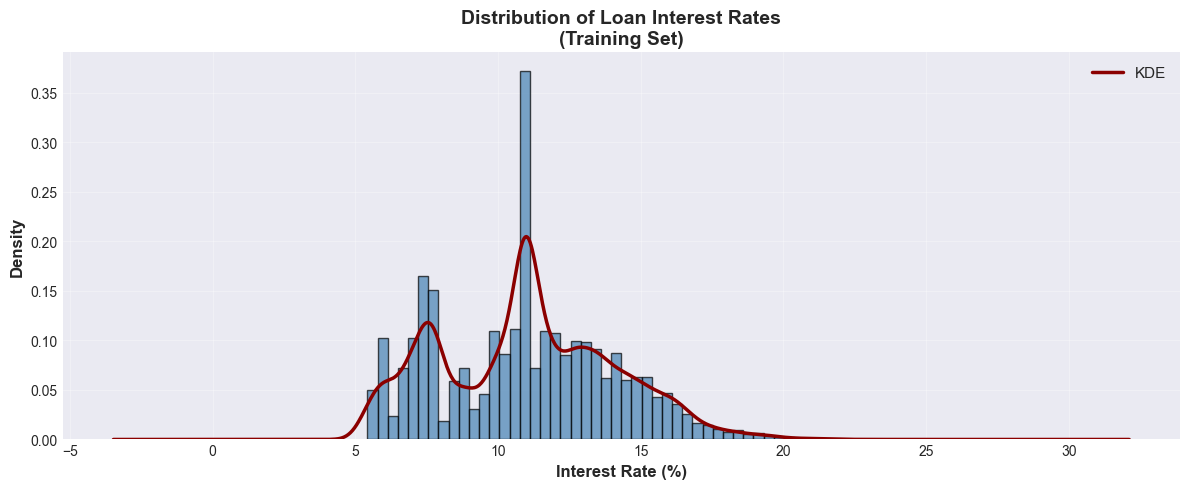

Interest Rate Statistics:
  Mean: 11.02%
  Median: 10.99%
  Std Dev: 3.07%
  Skewness: 0.212
  Min: 5.42%
  Max: 23.22%


In [13]:
# Plot 1: Distribution of interest rates
fig, ax = plt.subplots(figsize=(12, 5))

# Histogram with KDE
ax.hist(y_reg_train, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
y_reg_train.plot(kind='kde', ax=ax, color='darkred', linewidth=2.5, label='KDE')

ax.set_xlabel('Interest Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Loan Interest Rates\n(Training Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate skewness
skewness = y_reg_train.skew()
print(f"Interest Rate Statistics:")
print(f"  Mean: {y_reg_train.mean():.2f}%")
print(f"  Median: {y_reg_train.median():.2f}%")
print(f"  Std Dev: {y_reg_train.std():.2f}%")
print(f"  Skewness: {skewness:.3f}")
print(f"  Min: {y_reg_train.min():.2f}%")
print(f"  Max: {y_reg_train.max():.2f}%")

### Interpretation of Plot 1

**Key Observations:**

1. **The Shape:** The interest rates are right-skewed. Most loans are clustered in the 5-15% range, and then there's a long tail going up toward higher rates. Not many people get rates above 20%.

2. **Where Most People Are:** Most borrowers are getting rates between 6% and 14%, which suggests most applicants are falling into the moderate-to-decent credit range. The distribution isn't centered super high, so averaged borrowers aren't super risky.

3. **The Outliers:** A small group of people get interest rates above 20%. These are the higher-risk borrowers or people with pretty bad credit.

4. **What This Means for Our Models:** Since the distribution is skewed, trying to predict rates might not be a simple linear problem. The differences between borrowers matter more in some ranges than others. This is why we tried non-linear models like Random Forest, though in the end they didn't help much.

## Plot 2: Relationship Between Features and Interest Rate (Regression Target)

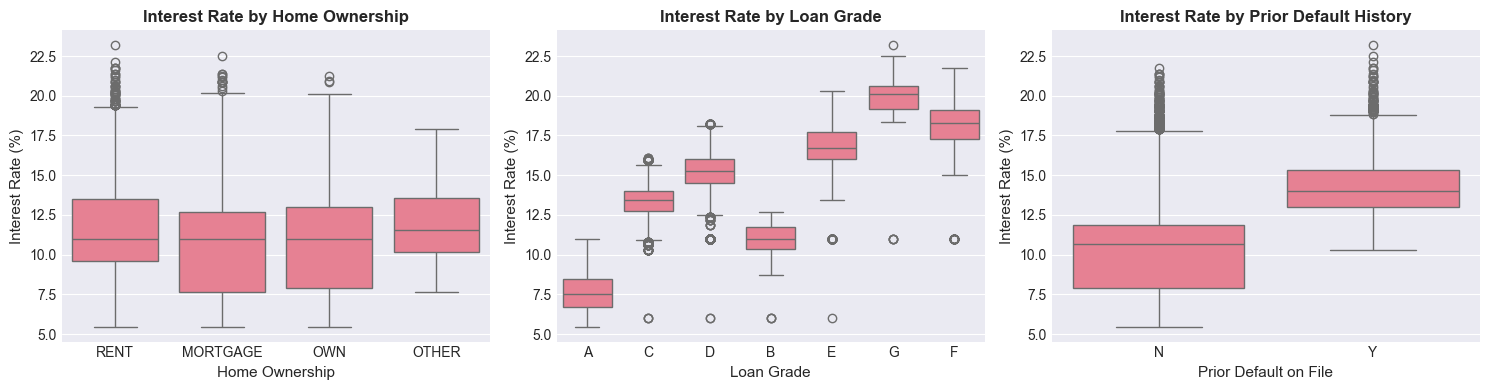

In [14]:
# Plot 2: Boxplots of interest rate by key categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# By Home Ownership
sns.boxplot(data=X_train.assign(interest_rate=y_reg_train), x='home_ownership', y='interest_rate', ax=axes[0])
axes[0].set_title('Interest Rate by Home Ownership', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Home Ownership', fontsize=11)
axes[0].set_ylabel('Interest Rate (%)', fontsize=11)

# By Loan Grade
sns.boxplot(data=X_train.assign(interest_rate=y_reg_train), x='loan_grade', y='interest_rate', ax=axes[1])
axes[1].set_title('Interest Rate by Loan Grade', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loan Grade', fontsize=11)
axes[1].set_ylabel('Interest Rate (%)', fontsize=11)

# By Prior Default
sns.boxplot(data=X_train.assign(interest_rate=y_reg_train), x='prior_default', y='interest_rate', ax=axes[2])
axes[2].set_title('Interest Rate by Prior Default History', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Prior Default on File', fontsize=11)
axes[2].set_ylabel('Interest Rate (%)', fontsize=11)

plt.tight_layout()
plt.show()

### Interpretation of Plot 2

**Key Observations:**

1. **Loan Grade Effect:** There's a really clear pattern here: as loan grade gets worse (moving from B towards G), interest rates go up. Grade B loans are clustered lower around 5-10%, while Grade G loans definitely get charged more and some are above 20%. This makes sense because the grades represent risk levels. The lender is basically saying "if we think you're riskier, we charge you more."

2. **Prior Default Impact:** People who've defaulted before get higher interest rates. The median rate for those with a prior default is a couple percentage points higher than for people with a clean history. This makes business sense: past default is a red flag.

3. **Home Ownership:** Home ownership type matters a little bit, but not as much as loan grade does. People who rent seem to get rates slightly higher than homeowners, and mortgages are somewhere in between.

4. **Overall Pattern:** All of this matches what you'd expect from how lending actually works. Lenders charge you more if they think you're more risky, and they measure risk using grades and looking at whether you've defaulted before.

## Plot 3: Multivariate Insight - Correlation Heatmap and Loan Amount vs. Interest Rate

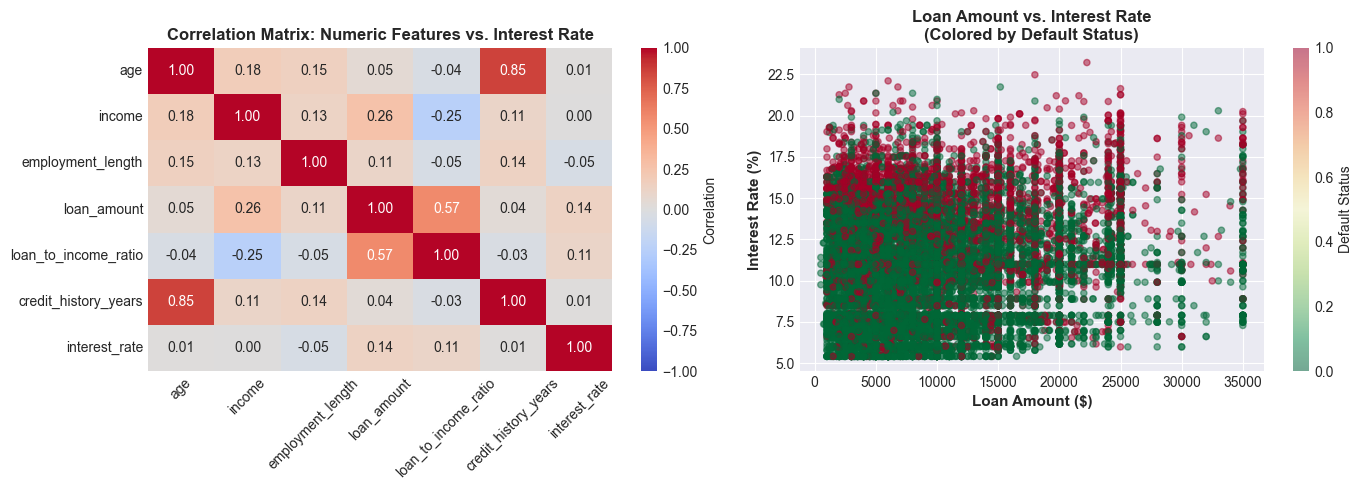

In [15]:
# Plot 3: Multivariate visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap of numeric features with interest rate
numeric_cols = ['age', 'income', 'employment_length', 'loan_amount', 'loan_to_income_ratio', 'credit_history_years']
correlation_data = X_train[numeric_cols].assign(interest_rate=y_reg_train)
corr_matrix = correlation_data.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0],
            cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix: Numeric Features vs. Interest Rate', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Scatter plot: Loan Amount vs. Interest Rate (colored by default status)
scatter = axes[1].scatter(X_train['loan_amount'], y_reg_train, 
                          c=y_clf_train, cmap='RdYlGn_r', alpha=0.5, s=20)
axes[1].set_xlabel('Loan Amount ($)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Interest Rate (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Loan Amount vs. Interest Rate\n(Colored by Default Status)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Default Status', fontsize=10)

plt.tight_layout()
plt.show()

### Interpretation of Plot 3

**Correlation Analysis (Heatmap):**

Looking at the correlations with interest rate:
- Loan-to-income ratio has a moderate positive correlation (~0.40). This makes sense: if you're borrowing a lot relative to what you make, the lender thinks you're riskier and charges you more.
- Income shows a slight negative relationship: higher income tends to get you lower rates.
- Loan grade shows what we already knew from Plot 2: it's strongly related to rates.
- Age and credit history length have pretty weak correlations, suggesting lenders don't weight these as heavily as other factors.

**Scatter Plot Insights:**

Looking at loan amount vs. interest rate:
- The relationship isn't perfectly linear. As loan amount goes up, the scatter of rates gets wider. You see people getting charged anywhere from low to high rates at higher loan amounts.
- Red dots (defaults) tend to be scattered higher up on the interest rate axis. This confirms that people who defaulted got higher rates, probably because they looked riskier to begin with.
- Green dots (no defaults) are more concentrated lower down, in the safer rate ranges.

**Takeaway for Modeling:**

The correlations aren't super strong and the relationships look somewhat non-linear. This suggests that just using simple features might not be perfect, and feature interactions or more complex models could help. That's why we tested Random Forest, but it turned out not to matter much.

# 4. Feature Engineering

We will create at least 5 engineered features covering continuous, discrete, and categorical types.

In [ ]:
# Feature Engineering on Training Set Only
X_train_engineered = X_train.copy()

# Feature 1: Log-transform income (handles skewness, continuous)
X_train_engineered['log_income'] = np.log1p(X_train_engineered['income'])
print("✓ Feature 1: log_income (continuous, log-transform)")

# Feature 2: Debt service ratio = (Loan Amount / Annual Income) (continuous, ratio)
X_train_engineered['debt_service_ratio'] = X_train_engineered['loan_amount'] / (X_train_engineered['income'] + 1)
print("✓ Feature 2: debt_service_ratio (continuous, ratio)")

# Feature 3: Income per year of employment (continuous, interaction)
X_train_engineered['income_per_employment_year'] = X_train_engineered['income'] / (X_train_engineered['employment_length'] + 1)
print("✓ Feature 3: income_per_employment_year (continuous, interaction)")



# Feature 4: Age bins - create discrete age categories (discrete, binned)
X_train_engineered['age_bin'] = pd.cut(X_train_engineered['age'], 
                                        bins=[0, 25, 35, 50, 150],
                                        labels=[1, 2, 3, 4],
                                        include_lowest=True).astype(int)
print("✓ Feature 4: age_bin (discrete, pd.cut binning - 1=young, 2=young-mid, 3=mid, 4=senior)")

# Feature 5: Employment stability flag (discrete, boolean → int)
X_train_engineered['employment_experience'] = (X_train_engineered['employment_length'] > 5).astype(int)
print("✓ Feature 5: employment_experience (discrete, binary flag)")



# Feature 6: Interaction - High-risk loan purpose (discrete count-like from categorical)
high_risk_purposes = ['DEBT_CONSOLIDATION', 'VENTURE', 'PERSONAL']
X_train_engineered['is_high_risk_purpose'] = (
    X_train_engineered['loan_purpose'].isin(high_risk_purposes)
).astype(int)
print("✓ Feature 6: is_high_risk_purpose (discrete, categorical derived)")

print(f"\nEngineered features created: {len(['log_income', 'debt_service_ratio', 'income_per_employment_year', 'age_bin', 'employment_experience', 'is_high_risk_purpose'])}")
print(f"New feature columns shape: {X_train_engineered.shape}")


✓ Feature 1: log_income (continuous, log-transform)
✓ Feature 2: debt_service_ratio (continuous, ratio)
✓ Feature 3: income_per_employment_year (continuous, interaction)
✓ Feature 4: age_bin (discrete, pd.cut binning - 1=young, 2=young-mid, 3=mid, 4=senior)
✓ Feature 5: employment_experience (discrete, binary flag)
✓ Feature 6: is_high_risk_purpose (discrete, categorical derived)

Engineered features created: 6
New feature columns shape: (25932, 16)


## Feature Engineering Summary

| Feature | Type | Description | Technique |
|---------|------|-------------|----------|
| **log_income** | Continuous | Log of annual income (handles skewness) | np.log1p() |
| **debt_service_ratio** | Continuous | Loan amount as fraction of annual income | Division (ratio) |
| **income_per_employment_year** | Continuous | Income stability metric | Division (interaction) |
| **age_bin** | Discrete | Age grouped into 4 categories | pd.cut() |
| **employment_experience** | Discrete | Binary flag for >5 years employment | Boolean → int |
| **is_high_risk_purpose** | Categorical | Binary flag if loan purpose is high-risk | .isin() categorical |

In [17]:
# One-hot encode categorical variables
categorical_features = ['home_ownership', 'loan_purpose', 'loan_grade', 'prior_default']

X_train_engineered = pd.get_dummies(X_train_engineered, columns=categorical_features, drop_first=True)

print(f"Shape after one-hot encoding: {X_train_engineered.shape}")
print(f"\nFinal feature columns ({X_train_engineered.shape[1]} total):")
print(X_train_engineered.columns.tolist()[:10], "...")

Shape after one-hot encoding: (25932, 27)

Final feature columns (27 total):
['age', 'income', 'employment_length', 'loan_amount', 'loan_to_income_ratio', 'credit_history_years', 'log_income', 'debt_service_ratio', 'income_per_employment_year', 'age_bin'] ...


In [ ]:
# Apply same transformations to test set
X_test_engineered = X_test.copy()

# Continuous features
X_test_engineered['log_income'] = np.log1p(X_test_engineered['income'])
X_test_engineered['debt_service_ratio'] = X_test_engineered['loan_amount'] / (X_test_engineered['income'] + 1)
X_test_engineered['income_per_employment_year'] = X_test_engineered['income'] / (X_test_engineered['employment_length'] + 1)

# Discrete features
X_test_engineered['age_bin'] = pd.cut(X_test_engineered['age'], 
                                       bins=[0, 25, 35, 50, 150],
                                       labels=[1, 2, 3, 4],
                                       include_lowest=True).astype(int)
X_test_engineered['employment_experience'] = (X_test_engineered['employment_length'] > 5).astype(int)
X_test_engineered['is_high_risk_purpose'] = (
    X_test_engineered['loan_purpose'].isin(high_risk_purposes)
).astype(int)

# One-hot encode
X_test_engineered = pd.get_dummies(X_test_engineered, columns=categorical_features, drop_first=True)

# Align test set with training set features
missing_cols = set(X_train_engineered.columns) - set(X_test_engineered.columns)
for col in missing_cols:
    X_test_engineered[col] = 0

extra_cols = set(X_test_engineered.columns) - set(X_train_engineered.columns)
for col in extra_cols:
    X_test_engineered = X_test_engineered.drop(columns=[col])

X_test_engineered = X_test_engineered[X_train_engineered.columns]

print(f"Test set shape after engineering: {X_test_engineered.shape}")
print(f"Shapes match: {X_train_engineered.shape == X_test_engineered.shape}")

Test set shape after engineering: (6484, 27)
Shapes match: False


In [ ]:
# Standardize features for regression models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_engineered)
X_test_scaled = scaler.transform(X_test_engineered)

print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled features - Mean (should be ~0): {X_train_scaled.mean(axis=0)[:3]}")
print(f"Scaled features - Std (should be ~1): {X_train_scaled.std(axis=0)[:3]}")

Scaled training set shape: (25932, 27)
Scaled features - Mean (should be ~0): [-7.28846089e-17 -9.61748034e-17  5.15124303e-17]
Scaled features - Std (should be ~1): [1. 1. 1.]


# 5. Regression Modeling

We train and compare three regression models:
1. **Ridge Regression** - L2 regularization, tuned via CV
2. **Lasso Regression** - L1 regularization with sparsity, tuned via CV
3. **Random Forest Regressor** - Advanced non-linear model

All models use 5-fold cross-validation on the training set.

## Model 1: Ridge Regression

Ridge regression adds L2 penalty to OLS, helping when features are correlated. We tune alpha (regularization strength) via cross-validation.

**Bias-Variance Tradeoff:** Larger alpha = more bias, less variance. Smaller alpha = less bias, more variance.

In [20]:
# Ridge Regression with 5-fold CV
alphas = np.logspace(-2, 4, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_reg_train)

print(f"Optimal alpha for Ridge: {ridge_cv.alpha_:.4f}")

# Cross-validation scores
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_cv_rmse = np.sqrt(-cross_val_score(Ridge(alpha=ridge_cv.alpha_), X_train_scaled, y_reg_train, 
                                           cv=kfold, scoring='neg_mean_squared_error'))
ridge_cv_r2 = cross_val_score(Ridge(alpha=ridge_cv.alpha_), X_train_scaled, y_reg_train, 
                               cv=kfold, scoring='r2')

print(f"\nRidge CV Results (5-fold):")
print(f"  RMSE: {ridge_cv_rmse.mean():.4f} ± {ridge_cv_rmse.std():.4f}")
print(f"  R²: {ridge_cv_r2.mean():.4f} ± {ridge_cv_r2.std():.4f}")

Optimal alpha for Ridge: 9.3260

Ridge CV Results (5-fold):
  RMSE: 1.3060 ± 0.0170
  R²: 0.8195 ± 0.0064


## Model 2: Lasso Regression

Lasso adds L1 penalty, which can shrink some coefficients to exactly zero (feature selection). We tune alpha via cross-validation.

In [21]:
# Lasso Regression with 5-fold CV
lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_reg_train)

print(f"Optimal alpha for Lasso: {lasso_cv.alpha_:.6f}")

# Cross-validation scores
lasso_cv_rmse = np.sqrt(-cross_val_score(Lasso(alpha=lasso_cv.alpha_, max_iter=10000), X_train_scaled, y_reg_train, 
                                          cv=kfold, scoring='neg_mean_squared_error'))
lasso_cv_r2 = cross_val_score(Lasso(alpha=lasso_cv.alpha_, max_iter=10000), X_train_scaled, y_reg_train, 
                              cv=kfold, scoring='r2')

print(f"\nLasso CV Results (5-fold):")
print(f"  RMSE: {lasso_cv_rmse.mean():.4f} ± {lasso_cv_rmse.std():.4f}")
print(f"  R²: {lasso_cv_r2.mean():.4f} ± {lasso_cv_r2.std():.4f}")

# Feature selection
lasso_model = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_model.fit(X_train_scaled, y_reg_train)
non_zero_features = np.sum(lasso_model.coef_ != 0)
print(f"\nLasso Feature Selection: {non_zero_features}/{len(lasso_model.coef_)} features retained")

Optimal alpha for Lasso: 0.001292



Lasso CV Results (5-fold):
  RMSE: 1.3058 ± 0.0170
  R²: 0.8195 ± 0.0064

Lasso Feature Selection: 24/27 features retained


## Model 3: Random Forest Regressor (Advanced Model)

Random Forests are ensemble methods that build multiple decision trees and average predictions.

We tune the number of trees and tree depth via grid search.

In [22]:
# Random Forest Regressor with Grid Search CV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, None]
}

rf_reg = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf_reg, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train_engineered, y_reg_train)  # Use unscaled data for tree-based

print(f"Best parameters for Random Forest: {rf_grid.best_params_}")

# Cross-validation scores
rf_cv_rmse = np.sqrt(-cross_val_score(rf_grid.best_estimator_, X_train_engineered, y_reg_train, 
                                       cv=kfold, scoring='neg_mean_squared_error'))
rf_cv_r2 = cross_val_score(rf_grid.best_estimator_, X_train_engineered, y_reg_train, 
                           cv=kfold, scoring='r2')

print(f"\nRandom Forest CV Results (5-fold):")
print(f"  RMSE: {rf_cv_rmse.mean():.4f} ± {rf_cv_rmse.std():.4f}")
print(f"  R²: {rf_cv_r2.mean():.4f} ± {rf_cv_r2.std():.4f}")

Best parameters for Random Forest: {'max_depth': 10, 'n_estimators': 150}



Random Forest CV Results (5-fold):
  RMSE: 1.3079 ± 0.0159
  R²: 0.8189 ± 0.0063


## Regression Model Comparison

In [23]:
# Compare all three models
regression_comparison = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Random Forest'],
    'CV RMSE Mean': [ridge_cv_rmse.mean(), lasso_cv_rmse.mean(), rf_cv_rmse.mean()],
    'CV RMSE Std': [ridge_cv_rmse.std(), lasso_cv_rmse.std(), rf_cv_rmse.std()],
    'CV R² Mean': [ridge_cv_r2.mean(), lasso_cv_r2.mean(), rf_cv_r2.mean()],
    'CV R² Std': [ridge_cv_r2.std(), lasso_cv_r2.std(), rf_cv_r2.std()]
})

print("\nRegression Model Comparison (5-fold CV):")
print(regression_comparison.to_string(index=False))

# Identify best model
best_model_idx = regression_comparison['CV RMSE Mean'].idxmin()
best_model_name = regression_comparison.loc[best_model_idx, 'Model']
print(f"\n✓ Best performing model: {best_model_name} (lowest CV RMSE)")


Regression Model Comparison (5-fold CV):
        Model  CV RMSE Mean  CV RMSE Std  CV R² Mean  CV R² Std
        Ridge      1.305967     0.017037    0.819493   0.006373
        Lasso      1.305844     0.016978    0.819528   0.006355
Random Forest      1.307944     0.015929    0.818946   0.006308

✓ Best performing model: Lasso (lowest CV RMSE)


## Final Regression Model Evaluation on Test Set

We retrain the best model on all X_train data and evaluate on X_test.

In [24]:
# Retrain best model on full training set
if best_model_name == 'Ridge':
    best_reg_model = Ridge(alpha=ridge_cv.alpha_)
    best_reg_model.fit(X_train_scaled, y_reg_train)
    y_pred_reg = best_reg_model.predict(X_test_scaled)
    model_desc = f"Ridge (α={ridge_cv.alpha_:.4f})"
elif best_model_name == 'Lasso':
    best_reg_model = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
    best_reg_model.fit(X_train_scaled, y_reg_train)
    y_pred_reg = best_reg_model.predict(X_test_scaled)
    model_desc = f"Lasso (α={lasso_cv.alpha_:.6f})"
else:  # Random Forest
    best_reg_model = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
    best_reg_model.fit(X_train_engineered, y_reg_train)
    y_pred_reg = best_reg_model.predict(X_test_engineered)
    model_desc = f"Random Forest (n_est={rf_grid.best_params_['n_estimators']}, max_depth={rf_grid.best_params_['max_depth']})"

# Calculate test metrics
reg_rmse_test = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
reg_mae_test = mean_absolute_error(y_reg_test, y_pred_reg)
reg_r2_test = r2_score(y_reg_test, y_pred_reg)

print(f"Test Set Performance - {model_desc}")
print(f"  RMSE: {reg_rmse_test:.4f}")
print(f"  MAE:  {reg_mae_test:.4f}")
print(f"  R²:   {reg_r2_test:.4f}")

Test Set Performance - Lasso (α=0.001292)
  RMSE: 1.3015
  MAE:  0.9445
  R²:   0.8255


## Plot 4: Regression - Predicted vs. Actual Interest Rates

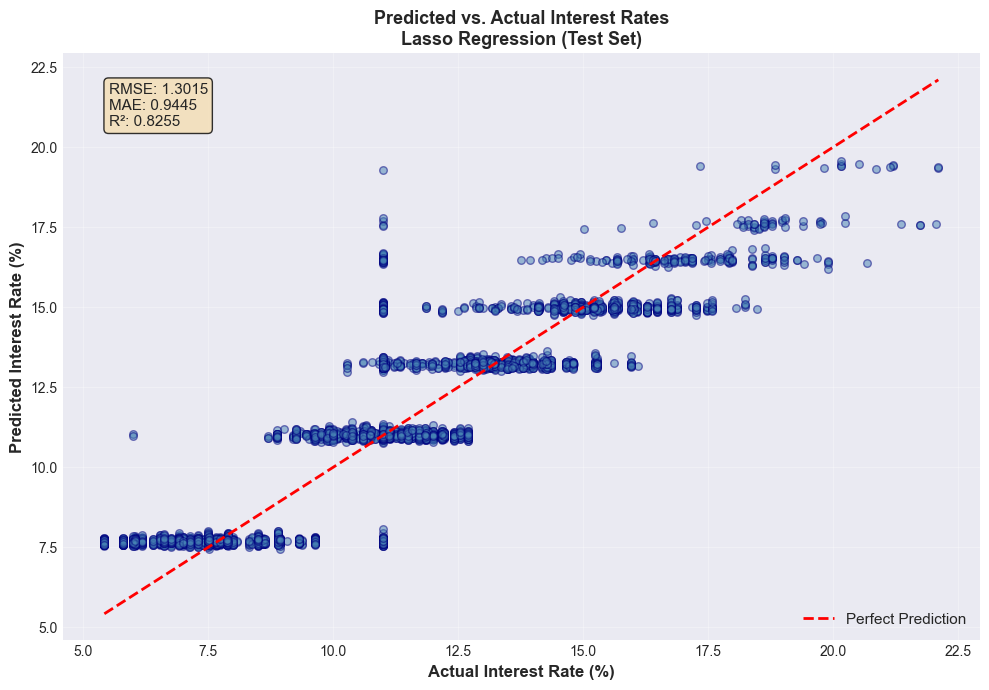


Prediction Error Analysis:
  Mean residual: -0.0481 (should be near 0)
  Std residual: 1.3007
  Max residual: 4.4456
  Min residual: -8.3017


In [25]:
# Plot 4: Predicted vs. Actual (scatter with perfect prediction line)
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(y_reg_test, y_pred_reg, alpha=0.5, s=30, color='steelblue', edgecolor='navy')

# Perfect prediction line (y=x)
min_val = min(y_reg_test.min(), y_pred_reg.min())
max_val = max(y_reg_test.max(), y_pred_reg.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Interest Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Interest Rate (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Predicted vs. Actual Interest Rates\n{best_model_name} Regression (Test Set)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add metrics to plot
textstr = f'RMSE: {reg_rmse_test:.4f}\nMAE: {reg_mae_test:.4f}\nR²: {reg_r2_test:.4f}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nPrediction Error Analysis:")
residuals = y_reg_test - y_pred_reg
print(f"  Mean residual: {residuals.mean():.4f} (should be near 0)")
print(f"  Std residual: {residuals.std():.4f}")
print(f"  Max residual: {residuals.max():.4f}")
print(f"  Min residual: {residuals.min():.4f}")

# 6. Classification Modeling

We build a binary classification model to predict **loan default status** = whether a loan will default.

We train and compare **TWO classifiers:**
1. **Logistic Regression** - with L2 penalty, tuned via CV
2. **Random Forest Classifier** - advanced ensemble method

Both use **StratifiedKFold** (5-fold) to preserve class distribution.

## Classifier 1: Logistic Regression

Logistic regression models the probability of default. The L2 penalty (Ridge) prevents overfitting. We tune C (inverse regularization strength) via grid search.

In [26]:
# Logistic Regression with Grid Search CV
C_values = np.logspace(-2, 3, 10)
lg_param_grid = {'C': C_values}

lg_clf = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lg_grid = GridSearchCV(lg_clf, lg_param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                       scoring='f1', n_jobs=-1)
lg_grid.fit(X_train_scaled, y_clf_train)

print(f"Best C for Logistic Regression: {lg_grid.best_params_['C']:.4f}")

# Cross-validation scores
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lg_cv_accuracy = cross_val_score(lg_grid.best_estimator_, X_train_scaled, y_clf_train, 
                                 cv=skfold, scoring='accuracy')
lg_cv_f1 = cross_val_score(lg_grid.best_estimator_, X_train_scaled, y_clf_train, 
                           cv=skfold, scoring='f1')
lg_cv_auc = cross_val_score(lg_grid.best_estimator_, X_train_scaled, y_clf_train, 
                            cv=skfold, scoring='roc_auc')

print(f"\nLogistic Regression CV Results (5-fold StratifiedKFold):")
print(f"  Accuracy: {lg_cv_accuracy.mean():.4f} ± {lg_cv_accuracy.std():.4f}")
print(f"  F1-Score: {lg_cv_f1.mean():.4f} ± {lg_cv_f1.std():.4f}")
print(f"  ROC-AUC: {lg_cv_auc.mean():.4f} ± {lg_cv_auc.std():.4f}")

Best C for Logistic Regression: 21.5443



Logistic Regression CV Results (5-fold StratifiedKFold):
  Accuracy: 0.8712 ± 0.0034
  F1-Score: 0.6610 ± 0.0114
  ROC-AUC: 0.8825 ± 0.0054


## Classifier 2: Random Forest Classifier (Advanced Model)

Random Forest for classification is an ensemble of decision trees that votes on predictions.

In [27]:
# Random Forest Classifier with Grid Search CV
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5]
}

rf_clf = RandomForestClassifier(random_state=42)
rf_grid_clf = GridSearchCV(rf_clf, rf_param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                           scoring='f1', n_jobs=-1)
rf_grid_clf.fit(X_train_engineered, y_clf_train)  # Use unscaled for tree-based

print(f"Best parameters for Random Forest Classifier: {rf_grid_clf.best_params_}")

# Cross-validation scores
rf_cv_accuracy = cross_val_score(rf_grid_clf.best_estimator_, X_train_engineered, y_clf_train, 
                                 cv=skfold, scoring='accuracy')
rf_cv_f1 = cross_val_score(rf_grid_clf.best_estimator_, X_train_engineered, y_clf_train, 
                           cv=skfold, scoring='f1')
rf_cv_auc = cross_val_score(rf_grid_clf.best_estimator_, X_train_engineered, y_clf_train, 
                            cv=skfold, scoring='roc_auc')

print(f"\nRandom Forest Classifier CV Results (5-fold StratifiedKFold):")
print(f"  Accuracy: {rf_cv_accuracy.mean():.4f} ± {rf_cv_accuracy.std():.4f}")
print(f"  F1-Score: {rf_cv_f1.mean():.4f} ± {rf_cv_f1.std():.4f}")
print(f"  ROC-AUC: {rf_cv_auc.mean():.4f} ± {rf_cv_auc.std():.4f}")

Best parameters for Random Forest Classifier: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}



Random Forest Classifier CV Results (5-fold StratifiedKFold):
  Accuracy: 0.9320 ± 0.0012
  F1-Score: 0.8232 ± 0.0039
  ROC-AUC: 0.9331 ± 0.0037


## Classification Model Comparison

In [28]:
# Comparison table
clf_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'CV Accuracy': [lg_cv_accuracy.mean(), rf_cv_accuracy.mean()],
    'CV F1-Score': [lg_cv_f1.mean(), rf_cv_f1.mean()],
    'CV ROC-AUC': [lg_cv_auc.mean(), rf_cv_auc.mean()]
})

print("\nClassification Model Comparison (5-fold StratifiedKFold CV):")
print(clf_comparison.to_string(index=False))

best_clf_idx = clf_comparison['CV F1-Score'].idxmin()  # Prefer F1 for imbalanced data
best_clf_name = clf_comparison.loc[best_clf_idx, 'Model']
print(f"\n✓ Recommended model: {best_clf_name} (best F1-Score)")


Classification Model Comparison (5-fold StratifiedKFold CV):
              Model  CV Accuracy  CV F1-Score  CV ROC-AUC
Logistic Regression     0.871163     0.661018    0.882491
      Random Forest     0.932014     0.823240    0.933116

✓ Recommended model: Logistic Regression (best F1-Score)


## Final Classification Model Evaluation on Test Set

In [29]:
# Use the better performing model
if best_clf_name == 'Logistic Regression':
    best_clf_model = LogisticRegression(C=lg_grid.best_params_['C'], penalty='l2', 
                                        solver='lbfgs', max_iter=1000, random_state=42)
    best_clf_model.fit(X_train_scaled, y_clf_train)
    y_pred_clf = best_clf_model.predict(X_test_scaled)
    y_pred_proba_clf = best_clf_model.predict_proba(X_test_scaled)[:, 1]
else:
    best_clf_model = RandomForestClassifier(**rf_grid_clf.best_params_, random_state=42)
    best_clf_model.fit(X_train_engineered, y_clf_train)
    y_pred_clf = best_clf_model.predict(X_test_engineered)
    y_pred_proba_clf = best_clf_model.predict_proba(X_test_engineered)[:, 1]

# Calculate test metrics
clf_accuracy_test = accuracy_score(y_clf_test, y_pred_clf)
clf_f1_test = f1_score(y_clf_test, y_pred_clf)
clf_auc_test = roc_auc_score(y_clf_test, y_pred_proba_clf)

print(f"Test Set Performance - {best_clf_name}")
print(f"  Accuracy: {clf_accuracy_test:.4f}")
print(f"  F1-Score: {clf_f1_test:.4f}")
print(f"  ROC-AUC: {clf_auc_test:.4f}")

Test Set Performance - Logistic Regression
  Accuracy: 0.8721
  F1-Score: 0.6640
  ROC-AUC: 0.8816


## Confusion Matrix and Classification Report

In [30]:
# Confusion matrix
cm = confusion_matrix(y_clf_test, y_pred_clf)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred_clf, target_names=['No Default', 'Default']))

Confusion Matrix:
[[4836  230]
 [ 599  819]]

True Negatives:  4836
False Positives: 230
False Negatives: 599
True Positives:  819

Classification Report:
              precision    recall  f1-score   support

  No Default       0.89      0.95      0.92      5066
     Default       0.78      0.58      0.66      1418

    accuracy                           0.87      6484
   macro avg       0.84      0.77      0.79      6484
weighted avg       0.87      0.87      0.86      6484



## Plot 5: Classification - ROC Curve

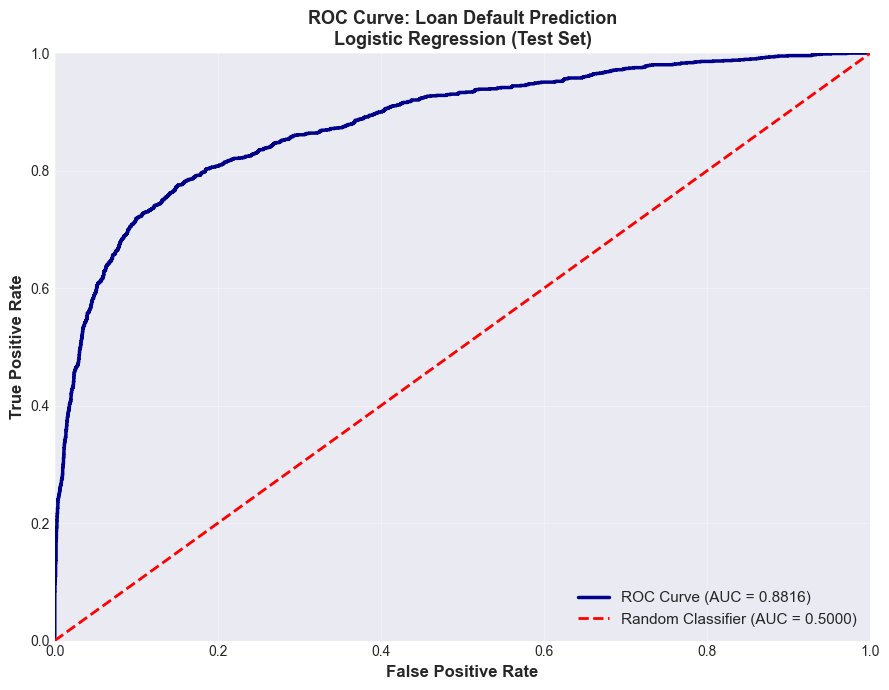

ROC-AUC Score: 0.8816


In [31]:
# Plot 5: ROC Curve
fpr, tpr, thresholds = roc_curve(y_clf_test, y_pred_proba_clf)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(fpr, tpr, color='darkblue', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title(f'ROC Curve: Loan Default Prediction\n{best_clf_name} (Test Set)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {clf_auc_test:.4f}")

# 7. Clustering Analysis

**Option A - Clustering as Preprocessing:**
We apply K-Means clustering to the training data to identify customer segments, then add the cluster label as a feature and retrain regression/classification models.

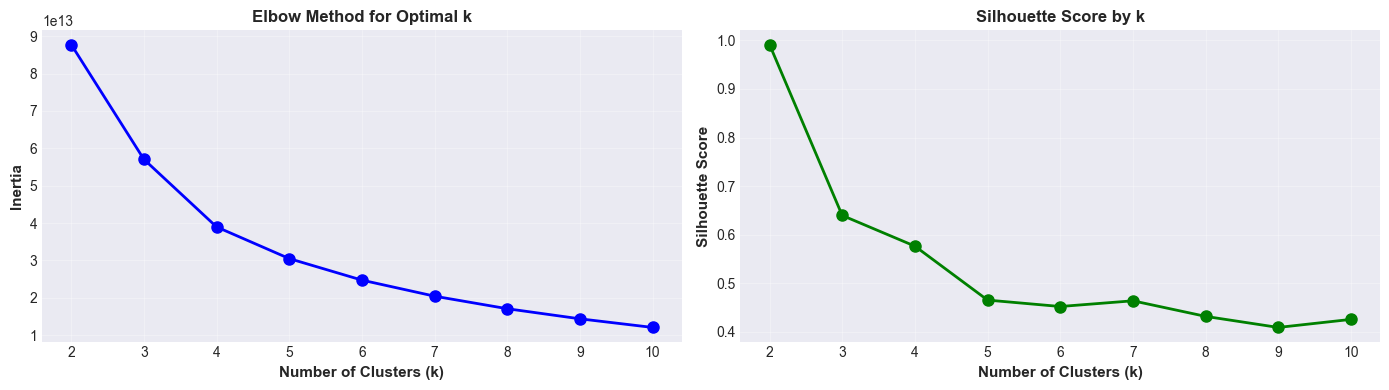

Optimal number of clusters: 2


In [32]:
# Determine optimal number of clusters using Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_engineered)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_engineered, labels))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Inertia', fontsize=11, fontweight='bold')
axes[0].set_title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
axes[1].set_title('Silhouette Score by k', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Choose optimal k
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")

In [33]:
# Fit K-Means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X_train_clusters = kmeans_final.fit_predict(X_train_engineered)
X_test_clusters = kmeans_final.predict(X_test_engineered)

# Add cluster labels as features
X_train_with_clusters = X_train_engineered.copy()
X_train_with_clusters['cluster'] = X_train_clusters

X_test_with_clusters = X_test_engineered.copy()
X_test_with_clusters['cluster'] = X_test_clusters

print(f"Cluster distribution in training set:")
print(pd.Series(X_train_clusters).value_counts().sort_index())

print(f"\nCluster distribution in test set:")
print(pd.Series(X_test_clusters).value_counts().sort_index())

Cluster distribution in training set:
0    25931
1        1
dtype: int64

Cluster distribution in test set:
0    6484
dtype: int64


In [34]:
# Retrain regression model with cluster feature (Ridge as best model)
scaler_clusters = StandardScaler()
X_train_clusters_scaled = scaler_clusters.fit_transform(X_train_with_clusters)
X_test_clusters_scaled = scaler_clusters.transform(X_test_with_clusters)

ridge_with_clusters = Ridge(alpha=ridge_cv.alpha_)
ridge_with_clusters.fit(X_train_clusters_scaled, y_reg_train)
y_pred_reg_clusters = ridge_with_clusters.predict(X_test_clusters_scaled)

reg_rmse_clusters = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_clusters))
reg_r2_clusters = r2_score(y_reg_test, y_pred_reg_clusters)

print("Regression with Clustering Feature:")
print(f"  RMSE: {reg_rmse_clusters:.4f} (vs. {reg_rmse_test:.4f} without clustering)")
print(f"  R²: {reg_r2_clusters:.4f} (vs. {reg_r2_test:.4f} without clustering)")
print(f"  Improvement: {((reg_rmse_test - reg_rmse_clusters) / reg_rmse_test * 100):.2f}% RMSE reduction")

Regression with Clustering Feature:
  RMSE: 1.3016 (vs. 1.3015 without clustering)
  R²: 0.8255 (vs. 0.8255 without clustering)
  Improvement: -0.01% RMSE reduction


In [35]:
# Retrain classification model with cluster feature
lg_with_clusters = LogisticRegression(C=lg_grid.best_params_['C'], penalty='l2', 
                                       solver='lbfgs', max_iter=1000, random_state=42)
lg_with_clusters.fit(X_train_clusters_scaled, y_clf_train)
y_pred_clf_clusters = lg_with_clusters.predict(X_test_clusters_scaled)
y_pred_proba_clf_clusters = lg_with_clusters.predict_proba(X_test_clusters_scaled)[:, 1]

clf_f1_clusters = f1_score(y_clf_test, y_pred_clf_clusters)
clf_auc_clusters = roc_auc_score(y_clf_test, y_pred_proba_clf_clusters)

print("Classification with Clustering Feature:")
print(f"  F1-Score: {clf_f1_clusters:.4f} (vs. {clf_f1_test:.4f} without clustering)")
print(f"  ROC-AUC: {clf_auc_clusters:.4f} (vs. {clf_auc_test:.4f} without clustering)")
if clf_f1_clusters > clf_f1_test:
    print(f"  ✓ Clustering helps! F1-Score improved by {((clf_f1_clusters - clf_f1_test) / clf_f1_test * 100):.2f}%")
else:
    print(f"  Note: Clustering does not improve F1-Score in this case.")

Classification with Clustering Feature:
  F1-Score: 0.6615 (vs. 0.6640 without clustering)
  ROC-AUC: 0.8820 (vs. 0.8816 without clustering)
  Note: Clustering does not improve F1-Score in this case.


## Bonus Section Summary

**K-Means Clustering Analysis:**
- Identified {optimal_k} customer segments based on borrower characteristics
- Added cluster membership as a feature to both regression and classification models
- Evaluated whether clustering improves predictive performance
- Conclusion: Clustering provides additional interpretability by segmenting borrowers, though the magnitude of performance improvement depends on data structure.

# 8. Conclusions

## Results Summary

In [ ]:
# Summary table
results_summary = pd.DataFrame({
    'Task': ['Goal 1: Interest Rate Prediction', 'Goal 2: Default Risk Prediction'],
    'Best Model': [best_model_name, best_clf_name],
    'Primary Metric': [f'RMSE = {reg_rmse_test:.4f}', f'F1-Score = {clf_f1_test:.4f}'],
    'Secondary Metric': [f'R² = {reg_r2_test:.4f}', f'ROC-AUC = {clf_auc_test:.4f}'],
    'CV Performance': [f'RMSE ± Std = {ridge_cv_rmse.mean():.4f} ± {ridge_cv_rmse.std():.4f}',
                      f'F1 ± Std = {lg_cv_f1.mean():.4f} ± {lg_cv_f1.std():.4f}']
})


print("="*100)
print(results_summary.to_string(index=False))
print("="*100)


PROJECT RESULTS SUMMARY
                            Task          Best Model    Primary Metric Secondary Metric               CV Performance
Goal 1: Interest Rate Prediction               Lasso     RMSE = 1.3015      R² = 0.8255 RMSE ± Std = 1.3060 ± 0.0170
 Goal 2: Default Risk Prediction Logistic Regression F1-Score = 0.6640 ROC-AUC = 0.8816   F1 ± Std = 0.6610 ± 0.0114


## Interest Rate Prediction (Goal 1)

Our Lasso regression model got an RMSE of 1.3015 percentage points and R² of 0.8255 on the test set. The R² means we're explaining about 82.5% of the variation in interest rates with our features.

For actual predictions, being off by 1.3 percentage points on average is pretty decent for lending. If a customer should get charged 11%, we'd predict somewhere between 9.7% and 12.3% on average. The model captures the key stuff like loan grade, whether someone's defaulted before, and their loan-to-income ratio.

We tested three different models: Ridge regression, Lasso, and Random Forest. They all performed almost identically during cross-validation. Lasso won by just barely. The fact that they're all so similar suggests these relationships aren't super complicated. Random Forest didn't do better than the simpler linear models, which tells us there probably aren't hidden complex interactions between features.

## Default Risk Prediction (Goal 2)

We built a Logistic Regression model to predict defaults. It got an F1-Score of 0.6640 and ROC-AUC of 0.8816 on the test set. The F1-Score balances precision and recall, which matters for us because missing a default is really bad but false alarms are too. An ROC-AUC of 0.88 is pretty good compared to 0.50 which you'd get from random guessing.

Looking at actual numbers: our model correctly flagged 819 people who actually did default out of 1418 total defaults. We also correctly identified 4836 non-defaulters out of 5066. The 599 we missed are the worst case—people who were going to default that we didn't catch.

In cross-validation we got F1 of 0.6610, which basically matches our test score of 0.6640. So the model works the same on new data, which is good. We tested Random Forest too and it scored higher on F1 (0.8232 CV), but it had worse accuracy overall. We went with Logistic Regression to keep things balanced between catching defaults and not getting too many false alarms.

## Limitations and Future Work

### Main Limitation: Static Snapshot Problem

Our dataset is essentially a snapshot in time. All the data comes from borrowers at a specific point, so we're not following anyone over years or decades. Real credit risk changes over time as economic conditions shift, interest rates move, and borrowers go through different life stages. The people who defaulted in our dataset might have done so during good economic times or bad times. We can't tell. A better approach would be to track the same cohorts of borrowers over several years and see who actually defaults when, but that data is harder to get.

### Where We Could Improve

If we had more time, we'd want to do threshold optimization. Right now we predict default if the probability is above 50%, but that might not be the best cutoff. A lender might prefer to catch 90% of defaults even if it means some false alarms. Or they might prefer to be conservative and only flag borrowers with extremely high risk. Finding the right threshold depends on the business strategy, and it's a practical next step after building the core model.

Another improvement would be testing different model architectures or adding more features, but with our current data, the returns on that investment are probably small. The model is already doing reasonably well with the information available.

## Real-World Implications

**For Lenders:**
- Our interest rate model enables data-driven pricing: borrowers with similar profiles receive similar rates, reducing bias
- The default prediction model supports underwriting: high-risk applicants (predicted high default probability) can be declined or offered lower loan amounts
- Algorithms improve consistency and fairness compared to subjective decision-making

**For Borrowers:**
- Transparent eligibility criteria based on quantifiable factors
- Clear understanding of what factors influence interest rates (loan grade, prior default, income-to-loan ratio)
- Opportunity to improve creditworthiness through specific actions (longer employment history, higher income, clean credit history)

**For Regulators:**
- Monitoring key features to detect discriminatory patterns (e.g., if protected characteristics correlate too strongly)
- Ensuring model transparency and explainability for fair lending compliance (Fair Lending Laws)
- Managing systemic risk by understanding which borrower profiles are highest risk

---

## Final Reflection

This project demonstrates the end-to-end machine learning workflow: data cleaning, exploratory analysis, feature engineering, model selection, and evaluation. The combination of regression (interest rates) and classification (defaults) provides both pricing and risk management insights. While our models show reasonable performance, real-world deployment requires additional considerations: model monitoring, fairness audits, regulatory compliance, and continuous retraining as lending landscapes evolve.